# 🧱 Backfill Planner

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/backfill-planner/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/backfill-planner/demo.ipynb)

**Pain point:** *"Backfills are error-prone manual scripts."*

Split a date range into idempotent chunks, persist every chunk's status to disk, retry flaky failures, quarantine structural ones, and resume after a crash without re-running a single success.

**What this notebook covers:**
1. The planner — chunking, JSON state store, retry/resume driver
2. Planning a 6-month weekly backfill
3. Running it against a flaky job (plus one structurally broken day)
4. The chunk map — what succeeded, what's dead
5. Crash-resume proof
6. Try your own range


## Step 1 — The planner

Three pieces:
- **`plan_chunks`** — split `[start, end)` into non-overlapping daily/weekly/monthly chunks (weekly aligns to Mondays). Each chunk is the unit of work *and* the unit of retry — which only works if the job is idempotent per chunk (`DELETE WHERE date BETWEEN … ; INSERT`).
- **`BackfillState`** — every status change is written to a JSON file immediately. Kill the process at any point; a new run picks up exactly where it stopped and never re-runs a success.
- **`run_backfill`** — pulls runnable chunks (pending first, then failures under the attempt cap), runs them, records duration and error, repeats until nothing is runnable. Three strikes → the chunk is dead and waits for a human.


In [1]:
from __future__ import annotations

import json
from dataclasses import asdict, dataclass
from datetime import date, timedelta
from pathlib import Path
from typing import Dict, List, Optional

GRANULARITIES = ("daily", "weekly", "monthly")
STATUSES = ("pending", "running", "success", "failed")


@dataclass
class Chunk:
    chunk_id: str
    start: str  # inclusive ISO date
    end: str    # exclusive ISO date
    status: str = "pending"
    attempts: int = 0
    duration_s: Optional[float] = None
    error: Optional[str] = None


def plan_chunks(start: date, end: date, granularity: str = "daily") -> List[Chunk]:
    """Split [start, end) into idempotent, non-overlapping chunks. Each chunk = one re-runnable unit."""
    if granularity not in GRANULARITIES:
        raise ValueError(f"granularity must be one of {GRANULARITIES}")
    if start >= end:
        raise ValueError("start must be before end")
    chunks: List[Chunk] = []
    cur = start
    while cur < end:
        if granularity == "daily":
            nxt = cur + timedelta(days=1)
        elif granularity == "weekly":
            nxt = cur + timedelta(days=7 - cur.weekday())  # align to Monday
        else:
            nxt = (cur.replace(day=1) + timedelta(days=32)).replace(day=1)
        nxt = min(nxt, end)
        chunks.append(Chunk(chunk_id=f"{granularity[0]}-{cur.isoformat()}", start=cur.isoformat(),
                            end=nxt.isoformat()))
        cur = nxt
    return chunks


class BackfillState:
    """JSON-persisted plan: survives crashes, resumes where it stopped, never re-runs successes."""

    def __init__(self, path: str) -> None:
        self.path = Path(path)
        self.chunks: List[Chunk] = []
        if self.path.exists():
            self.chunks = [Chunk(**c) for c in json.loads(self.path.read_text())["chunks"]]

    def init_plan(self, chunks: List[Chunk]) -> None:
        if not self.chunks:  # never clobber an in-progress plan
            self.chunks = chunks
            self._save()

    def _save(self) -> None:
        self.path.write_text(json.dumps({"chunks": [asdict(c) for c in self.chunks]}, indent=2))

    def next_batch(self, max_parallel: int = 4, max_attempts: int = 3) -> List[Chunk]:
        """Runnable chunks: pending first, then retryable failures. Respects the parallelism cap."""
        running = sum(1 for c in self.chunks if c.status == "running")
        slots = max(0, max_parallel - running)
        candidates = [c for c in self.chunks if c.status == "pending"] + \
                     [c for c in self.chunks if c.status == "failed" and c.attempts < max_attempts]
        return candidates[:slots]

    def mark(self, chunk_id: str, status: str, duration_s: Optional[float] = None,
             error: Optional[str] = None) -> None:
        for c in self.chunks:
            if c.chunk_id == chunk_id:
                c.status = status
                if status == "running":
                    c.attempts += 1
                if duration_s is not None:
                    c.duration_s = duration_s
                c.error = error
                break
        self._save()

    def summary(self) -> Dict[str, object]:
        counts = {s: sum(1 for c in self.chunks if c.status == s) for s in STATUSES}
        done = [c for c in self.chunks if c.status == "success" and c.duration_s]
        avg = sum(c.duration_s for c in done) / len(done) if done else None
        remaining = counts["pending"] + counts["failed"]
        dead = [c for c in self.chunks if c.status == "failed" and c.attempts >= 3]
        return {
            "total": len(self.chunks), **counts,
            "avg_chunk_seconds": round(avg, 1) if avg else None,
            "eta_seconds_serial": round(avg * remaining, 1) if avg else None,
            "dead_chunks": [c.chunk_id for c in dead],
            "pct_complete": round(100 * counts["success"] / len(self.chunks), 1) if self.chunks else 0,
        }


def run_backfill(state: BackfillState, job_fn, max_parallel: int = 4, max_attempts: int = 3,
                 max_cycles: int = 1000) -> Dict[str, object]:
    """Drive the plan to completion: pull a batch, run each chunk, record outcome, repeat.
    job_fn(chunk) -> duration_s, raises on failure. Idempotent chunks make retries safe."""
    import time
    for _ in range(max_cycles):
        batch = state.next_batch(max_parallel, max_attempts)
        if not batch:
            break
        for chunk in batch:
            state.mark(chunk.chunk_id, "running")
            t0 = time.perf_counter()
            try:
                job_fn(chunk)
                state.mark(chunk.chunk_id, "success", duration_s=time.perf_counter() - t0)
            except Exception as exc:
                state.mark(chunk.chunk_id, "failed", duration_s=time.perf_counter() - t0,
                           error=str(exc))
    return state.summary()


## Step 2 — Plan 6 months, weekly

27 chunks, each one Monday-aligned week.

In [2]:
import tempfile
from datetime import date
from pathlib import Path

chunks = plan_chunks(date(2026, 1, 1), date(2026, 7, 1), granularity="weekly")
print(f"{len(chunks)} chunks: {chunks[0].chunk_id} … {chunks[-1].chunk_id}")
for c in chunks[:3]:
    print(f"  {c.chunk_id}: [{c.start} → {c.end})")

27 chunks: w-2026-01-01 … w-2026-06-29
  w-2026-01-01: [2026-01-01 → 2026-01-05)
  w-2026-01-05: [2026-01-05 → 2026-01-12)
  w-2026-01-12: [2026-01-12 → 2026-01-19)


## Step 3 — Run against a flaky world

The simulated job fails 25% of the time at random (upstream timeouts) — and the week containing 2026-03-02 is *structurally* broken (corrupt source partition): it fails every attempt. Watch retries absorb the flakiness while the broken chunk goes dead after 3 strikes.

In [3]:
import random

state_path = str(Path(tempfile.mkdtemp()) / "backfill.json")
state = BackfillState(state_path)
state.init_plan(chunks)

rng = random.Random(11)

def flaky_job(chunk):
    if chunk.start == "2026-03-02":
        raise RuntimeError("corrupt source partition — needs manual fix")
    if rng.random() < 0.25:
        raise RuntimeError("simulated upstream timeout")

summary = run_backfill(state, flaky_job, max_parallel=4, max_attempts=3)
for k in ("total", "success", "failed", "pct_complete"):
    print(f"{k:14s} {summary[k]}")
print(f"{'dead chunks':14s} {summary['dead_chunks']}")

retried = [c for c in state.chunks if c.status == "success" and c.attempts > 1]
print(f"\n{len(retried)} chunks needed retries and still succeeded:")
for c in retried:
    print(f"  {c.chunk_id}: {c.attempts} attempts")

total          27
success        26
failed         1
pct_complete   96.3
dead chunks    ['w-2026-03-02']

9 chunks needed retries and still succeeded:
  w-2026-02-09: 3 attempts
  w-2026-03-16: 2 attempts
  w-2026-03-30: 2 attempts
  w-2026-04-20: 2 attempts
  w-2026-05-25: 2 attempts
  w-2026-06-01: 2 attempts
  w-2026-06-15: 2 attempts
  w-2026-06-22: 2 attempts
  w-2026-06-29: 2 attempts


## Step 4 — The chunk map

One bar per chunk on the calendar. Green = done, red = dead and waiting for a human.

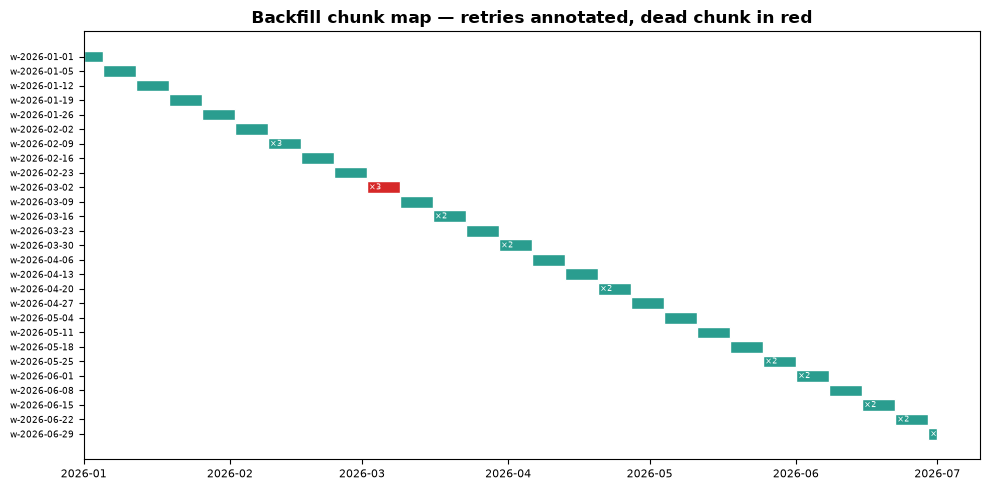

In [4]:
import matplotlib.pyplot as plt
from datetime import date as _date

colors = {"success": "#2a9d8f", "failed": "#d62828", "pending": "#adb5bd", "running": "#e9c46a"}
fig, ax = plt.subplots(figsize=(10, 5))
for i, c in enumerate(state.chunks):
    s, e = _date.fromisoformat(c.start), _date.fromisoformat(c.end)
    ax.barh(i, (e - s).days, left=s.toordinal(), color=colors[c.status], edgecolor="white")
    if c.attempts > 1:
        ax.text(s.toordinal() + 0.5, i, f"×{c.attempts}", va="center", fontsize=6, color="white")
ax.set_yticks(range(len(state.chunks)))
ax.set_yticklabels([c.chunk_id for c in state.chunks], fontsize=6.5)
ax.set_xticks([_date(2026, m, 1).toordinal() for m in range(1, 8)])
ax.set_xticklabels([f"2026-{m:02d}" for m in range(1, 8)], fontsize=8)
ax.invert_yaxis()
ax.set_title("Backfill chunk map — retries annotated, dead chunk in red", fontweight="bold")
fig.tight_layout()
fig.savefig("backfill_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Crash-resume proof

Reload the state file as if the process had died. Successes are preserved; only the dead chunk is left — and after the "source is fixed", one more run finishes the job.

In [5]:
resumed = BackfillState(state_path)   # fresh object, same file — simulates a new process
done_before = sum(1 for c in resumed.chunks if c.status == "success")
print(f"resumed from disk: {done_before}/{len(resumed.chunks)} already done — will NOT re-run")

def fixed_job(chunk):
    pass  # upstream repaired

# allow one more attempt for the dead chunk
final = run_backfill(resumed, fixed_job, max_parallel=4, max_attempts=4)
print(f"after fix: {final['success']}/{final['total']} complete ({final['pct_complete']}%)")

resumed from disk: 26/27 already done — will NOT re-run
after fix: 27/27 complete (100.0%)


## Summary

| Property | How |
|---|---|
| No lost work | every status change hits disk before the next chunk runs |
| Flaky failures | retried up to 3 attempts, absorbed silently |
| Structural failures | dead after 3 strikes, named in the summary, wait for a human |
| Resume | new process + same JSON = continue, never repeat a success |
| Safe retries | chunks are idempotent units — delete-and-reload per date range |

That's the difference between "re-run the script and hope" and a backfill you can kill at 6pm and resume at 9am.


## Try your own

In [6]:
# my_chunks = plan_chunks(date(2025, 1, 1), date(2026, 1, 1), granularity="monthly")
# my_state = BackfillState("my_backfill.json")
# my_state.init_plan(my_chunks)
#
# def my_job(chunk):
#     # idempotent load for [chunk.start, chunk.end) — e.g.:
#     # DELETE FROM target WHERE dt >= chunk.start AND dt < chunk.end; INSERT ...
#     ...
#
# print(run_backfill(my_state, my_job, max_parallel=8))

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
